# SSL pretraining demo: one EchoNet-LVH video sample

Walk through one video end to end: raw video → clip sampling → augmentation → dataset output → SimCLR forward pass + loss.

Run with the project `.venv` kernel; the notebook expects to be run from inside `ssl_pretraining/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

In [20]:
SSL_DIR = Path.cwd() / "ssl_pretraining"
sys.path.insert(0, str(SSL_DIR))

from dataset import EchoNetLVHDataset
from dataset import lvh_labels
from losses import NT_Xent
from model import SimCLR
from utils import load_video, set_seed


DATA_DIR = SSL_DIR.parent / "data"
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
set_seed(0)
print(f"data_dir={DATA_DIR}  device={DEVICE}  torch={torch.__version__}")


def show_clip(clip, title=""):
    """Plot the frames of a (T, H, W, C) clip side by side."""
    fig, axes = plt.subplots(1, len(clip), figsize=(3 * len(clip), 3))
    for t, ax in enumerate(np.atleast_1d(axes)):
        frame = clip[t]
        ax.imshow(frame if frame.dtype == np.uint8 else np.clip(frame, 0, 1))
        ax.set_title(f"frame {t}")
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

data_dir=/Users/howardbaek/Dropbox/Mac/Documents/echo-severe-as/data  device=mps  torch=2.14.0


## Build the dataset

Finds the `.avi` files under `data/Batch*/` for this split.

In [3]:
dataset = EchoNetLVHDataset(data_dir=str(DATA_DIR), split="train", clip_len=4)
fpath = dataset.fnames[0]
print(fpath)

train: found 10 of 10490 videos (10480 missing on disk)
/Users/howardbaek/Dropbox/Mac/Documents/echo-severe-as/data/Batch1/0X1A026FE97C81DF79.avi


## Raw video

Shape is (frames, height, width, channels)

(244, 600, 800, 3) uint8


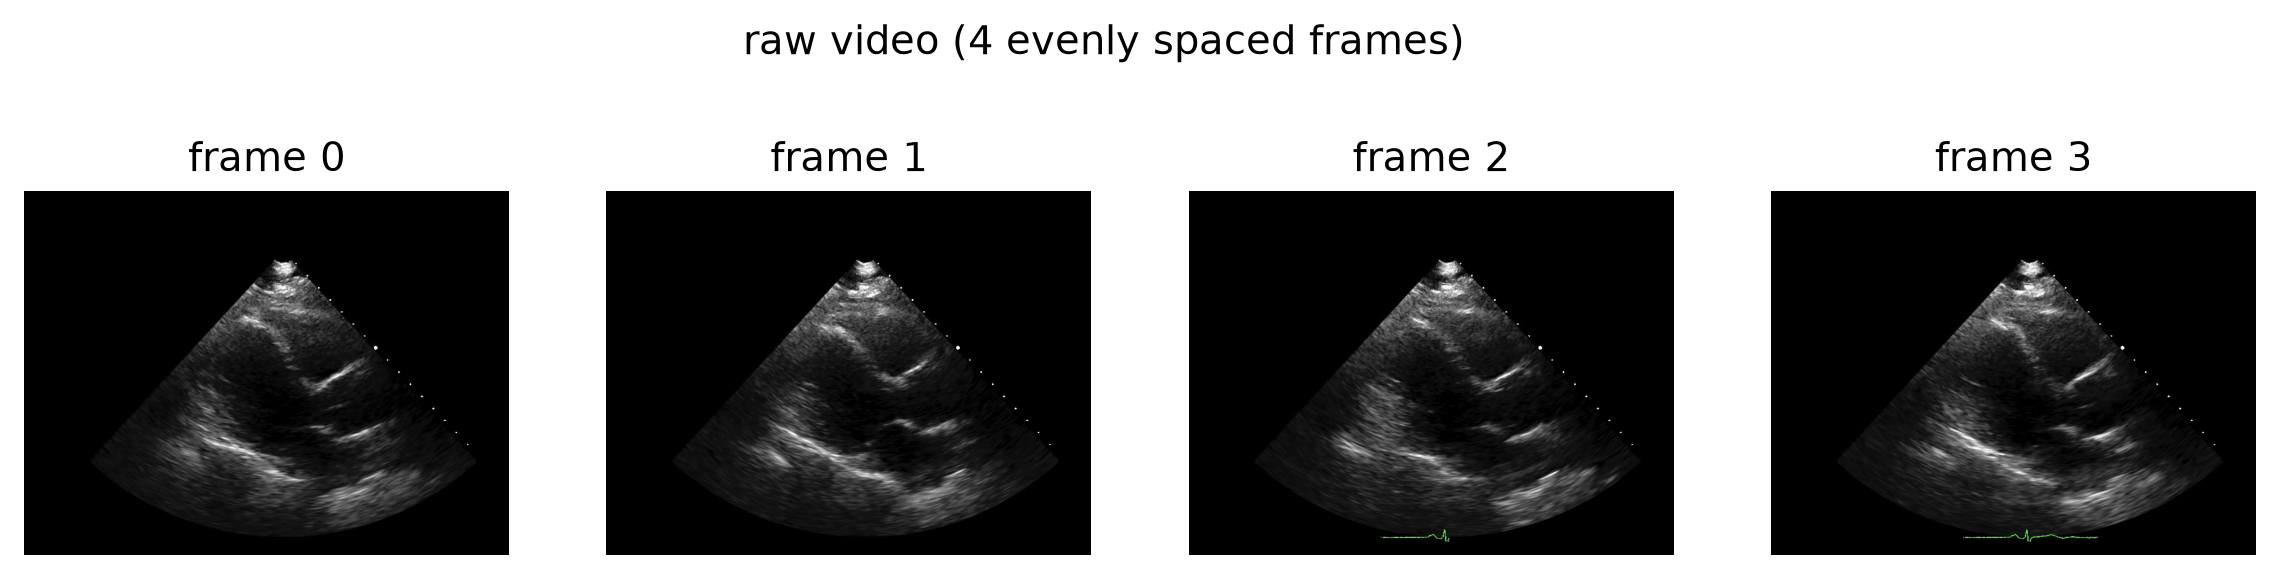

In [4]:
video = load_video(fpath)
print(video.shape, video.dtype)
show_clip(
    video[:: max(1, len(video) // 4)][:4, ..., ::-1],
    "raw video (4 evenly spaced frames)",
)

## The full `__getitem__` output

Two views, each (C, T, H, W), plus frame-order labels.

torch.Size([3, 4, 112, 112]) torch.Size([3, 4, 112, 112]) 3 19


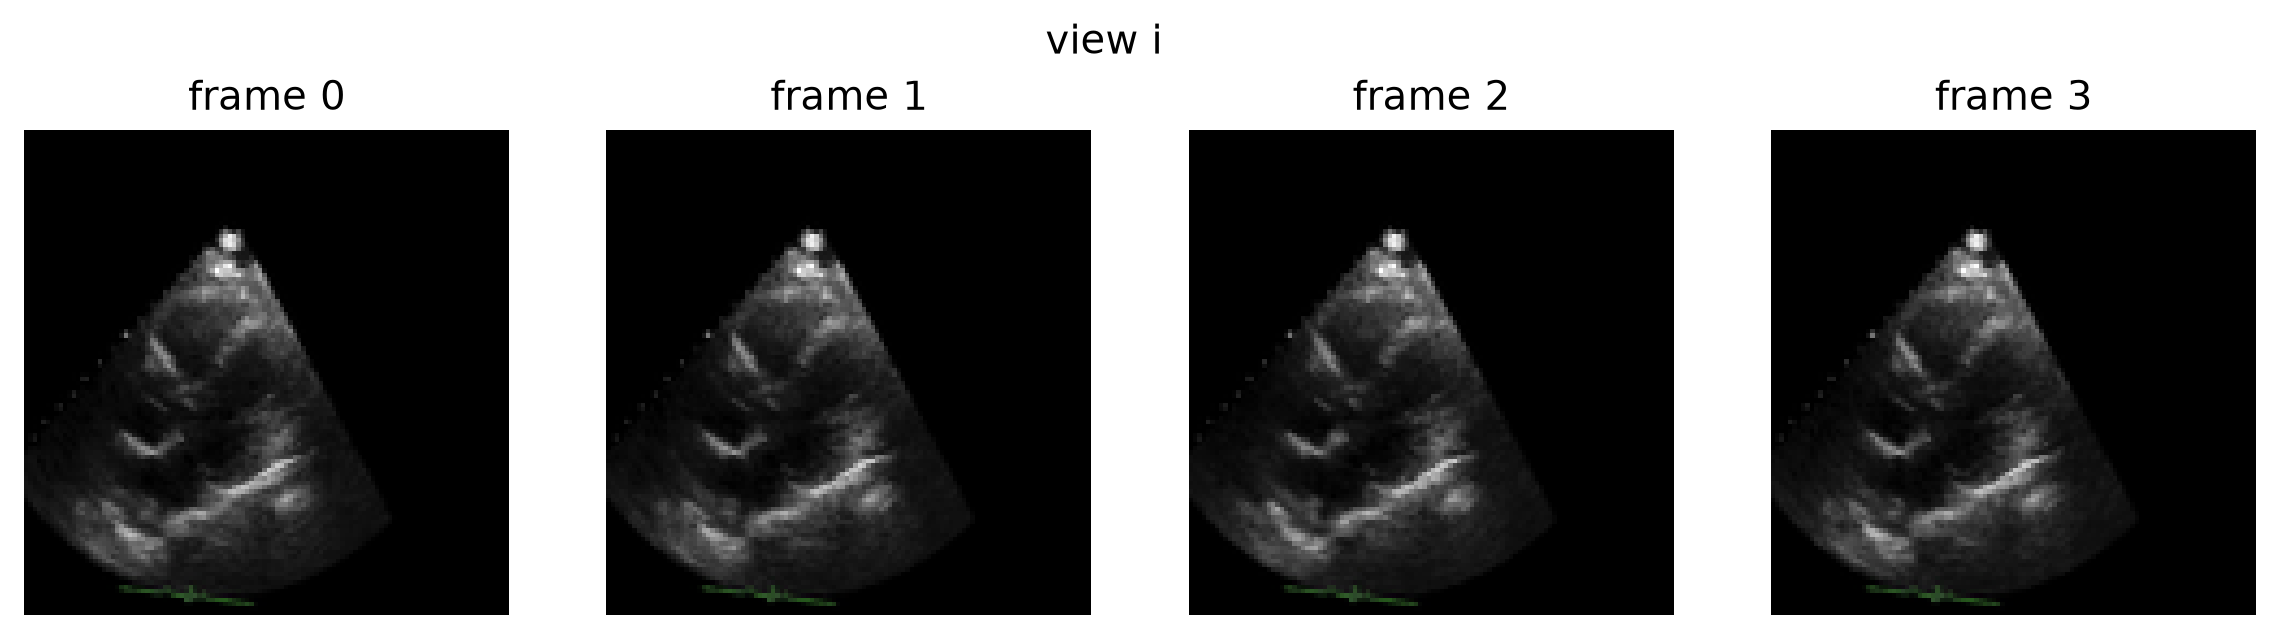

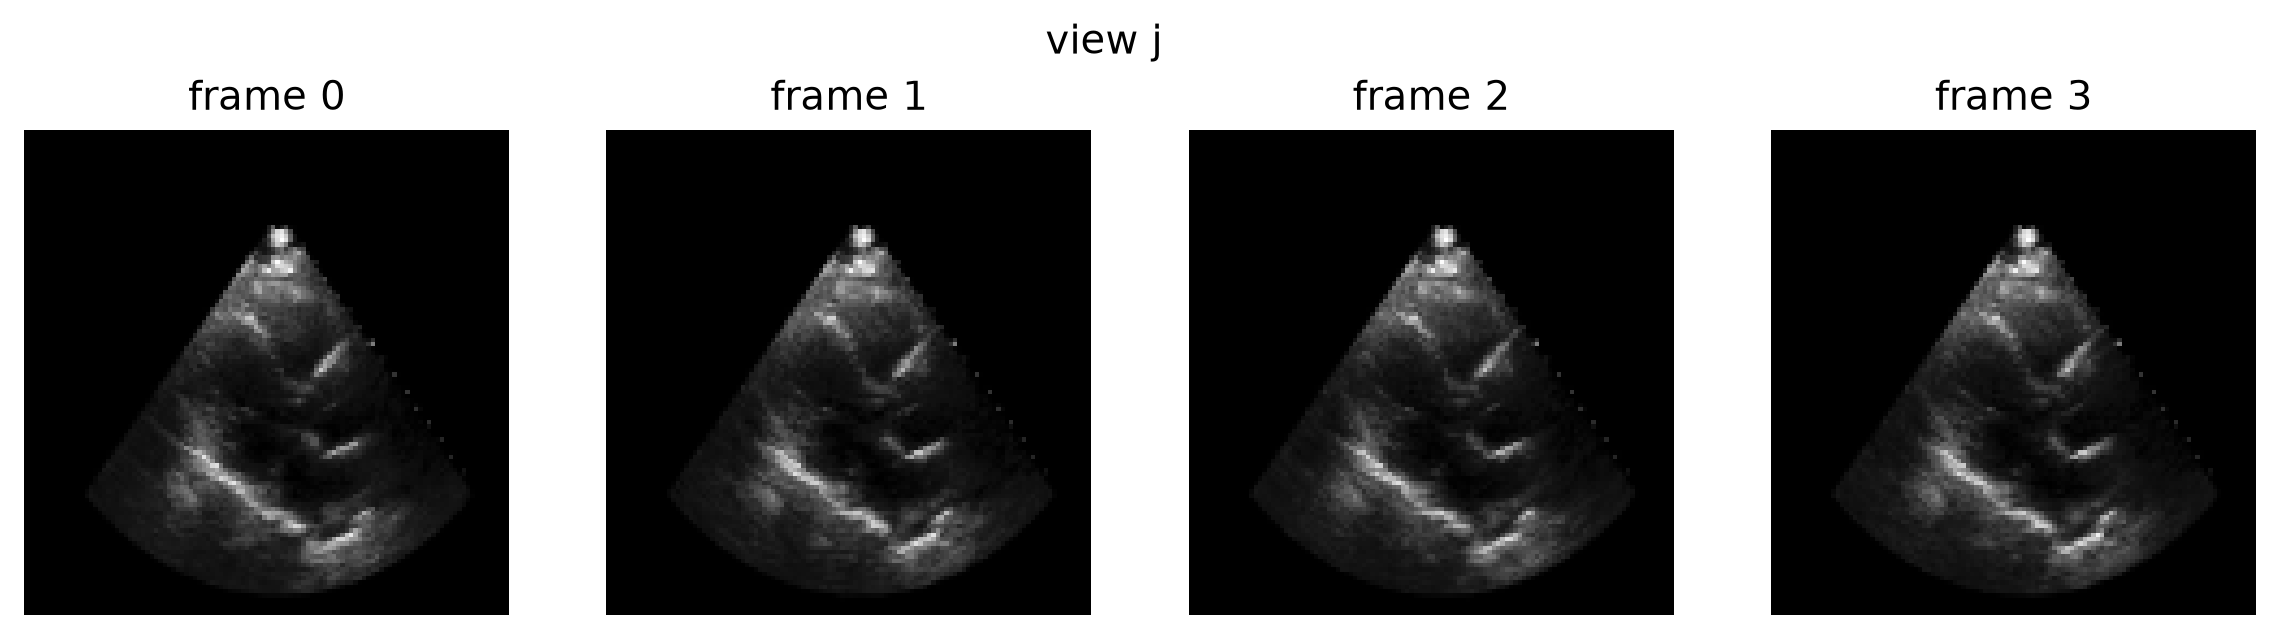

In [5]:
x_i, x_j, t_i, t_j = dataset[0]
print(x_i.shape, x_j.shape, t_i.item(), t_j.item())
show_clip(x_i.permute(1, 2, 3, 0).numpy()[..., ::-1], "view i")
show_clip(x_j.permute(1, 2, 3, 0).numpy()[..., ::-1], "view j")

## Step 4: forward a small batch through SimCLR and compute the pretraining loss

In [6]:
batch_size = 2
loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True, drop_last=True
)
x_i, x_j, t_i, t_j = [b.to(DEVICE) for b in next(iter(loader))]

encoder = torchvision.models.video.r3d_18(weights=None)
model = SimCLR(
    encoder=encoder, projection_dim=128, n_features=encoder.fc.in_features
).to(DEVICE)

with torch.no_grad():
    h_i, h_j, z_i, z_j, t_hat_i, t_hat_j = model(x_i, x_j)
print(
    "features h:",
    h_i.shape,
    " projections z:",
    z_i.shape,
    " reorder logits:",
    t_hat_i.shape,
)

contrastive = NT_Xent(batch_size, temperature=0.05)(z_i, z_j)
reorder = torch.nn.functional.cross_entropy(
    torch.cat([t_hat_i, t_hat_j]), torch.cat([t_i, t_j])
)
print(
    f"NT-Xent={contrastive.item():.4f}  reorder CE={reorder.item():.4f}  total={(contrastive + reorder).item():.4f}"
)

features h: torch.Size([2, 512])  projections z: torch.Size([2, 128])  reorder logits: torch.Size([2, 24])
NT-Xent=1.0536  reorder CE=3.0510  total=4.1046


## Training Loop: First Iteration

#### Copied from ssl_pretraining/main.py

In [7]:
import argparse
import os
import shutil

import pandas as pd
import torch
import torchvision
import tqdm
from dataset import EchoDataset
from losses import NT_Xent
from model import SimCLR
from utils import seed_worker, set_seed


In [8]:
data_dir = "./data"  # required, no default -- fill in
output_dir = "./output"  # required, no default -- fill in
model_name = "test-model"  # required, no default -- fill in

n_gpu = 1

batch_size = 2
temperature = 0.05
projection_dim = 128
lr = 0.1
num_epochs = 300
clip_len = 4
sampling_rate = 1

save_freq = 20


In [9]:
# Create output directory and clean out if already exists
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

model_dir = os.path.join(output_dir, model_name)

if os.path.isdir(model_dir):
    shutil.rmtree(model_dir)
os.mkdir(model_dir)

history = pd.DataFrame({"epoch": [], "loss": []})
history.to_csv(os.path.join(model_dir, "history.csv"), index=False)


In [10]:
# device = DEVICE  # cuda > mps > cpu, defined in the setup cell

# set_seed(0)

# train_dataset = EchoNetLVHDataset(
#     data_dir=str(DATA_DIR), split="train", clip_len=clip_len
# )
# train_loader = torch.utils.data.DataLoader(
#     train_dataset,
#     batch_size=n_gpu * batch_size,
#     worker_init_fn=seed_worker,
#     shuffle=True,
#     drop_last=True,
# )

# encoder = torchvision.models.video.r3d_18(weights=None)
# model = SimCLR(
#     encoder=encoder, projection_dim=projection_dim, n_features=encoder.fc.in_features
# )

# model = model.to(device)
# print(model)

# optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# loss_fxn = NT_Xent(batch_size, temperature, world_size=n_gpu)
# cls_loss_fxn = torch.nn.CrossEntropyLoss()

# model.train()
# for epoch in range(1, 1 + 1):
#     running_loss = 0.0
#     pbar = tqdm.tqdm(
#         enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}"
#     )

#     for i, batch in pbar:
#         x_i, x_j, t_i, t_j = batch
#         x_i = x_i.to(device)
#         x_j = x_j.to(device)
#         t_i = t_i.to(device)
#         t_j = t_j.to(device)

#         h_i, h_j, z_i, z_j, t_hat_i, t_hat_j = model(x_i, x_j)

#         loss = loss_fxn(z_i, z_j) + cls_loss_fxn(
#             torch.cat([t_hat_i, t_hat_j]), torch.cat([t_i, t_j])
#         )

#         # Backward pass
#         optimizer.zero_grad(set_to_none=True)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#         pbar.set_postfix({"loss": running_loss / (i + 1)})

#     current_metrics = pd.DataFrame({"epoch": [epoch], "loss": [running_loss / (i + 1)]})
#     current_metrics.to_csv(
#         os.path.join(model_dir, "history.csv"), mode="a", header=False, index=False
#     )

#     if epoch % save_freq == 0:
#         torch.save(
#             {
#                 "weights": model.module.state_dict()
#                 if isinstance(model, torch.nn.DataParallel)
#                 else model.state_dict(),
#                 "optimizer": optimizer.state_dict(),
#             },
#             os.path.join(model_dir, f"chkpt_epoch-{epoch}.pt"),
#         )


## Checkpoint

Examine SSL pretraining outputs:
- `ssl_pretraining/output/model-2026-1002/chkpt_epoch-120.pt`
- `ssl_pretraining/output/model-2026-1002/history.csv`


#### Checkpoint: Epoch 120

In [11]:
import torch

checkpoint = torch.load(
    "ssl_pretraining/output/model-2026-1002/chkpt_epoch-120.pt",
    map_location="cpu",
    weights_only=False,
)

print(type(checkpoint))
if isinstance(checkpoint, dict):
    for key, value in checkpoint.items():
        if hasattr(value, "shape"):
            print(f"{key}: tensor, shape={value.shape}, dtype={value.dtype}")
        elif isinstance(value, dict):
            print(f"{key}: dict with {len(value)} keys")
        else:
            print(f"{key}: {type(value)} -> {value}")

<class 'dict'>
weights: dict with 124 keys
optimizer: dict with 2 keys


In [12]:
for name, tensor in checkpoint["weights"].items():
    print(f"{name}: {tuple(tensor.shape)}")

encoder.stem.0.weight: (64, 3, 3, 7, 7)
encoder.stem.1.weight: (64,)
encoder.stem.1.bias: (64,)
encoder.stem.1.running_mean: (64,)
encoder.stem.1.running_var: (64,)
encoder.stem.1.num_batches_tracked: ()
encoder.layer1.0.conv1.0.weight: (64, 64, 3, 3, 3)
encoder.layer1.0.conv1.1.weight: (64,)
encoder.layer1.0.conv1.1.bias: (64,)
encoder.layer1.0.conv1.1.running_mean: (64,)
encoder.layer1.0.conv1.1.running_var: (64,)
encoder.layer1.0.conv1.1.num_batches_tracked: ()
encoder.layer1.0.conv2.0.weight: (64, 64, 3, 3, 3)
encoder.layer1.0.conv2.1.weight: (64,)
encoder.layer1.0.conv2.1.bias: (64,)
encoder.layer1.0.conv2.1.running_mean: (64,)
encoder.layer1.0.conv2.1.running_var: (64,)
encoder.layer1.0.conv2.1.num_batches_tracked: ()
encoder.layer1.1.conv1.0.weight: (64, 64, 3, 3, 3)
encoder.layer1.1.conv1.1.weight: (64,)
encoder.layer1.1.conv1.1.bias: (64,)
encoder.layer1.1.conv1.1.running_mean: (64,)
encoder.layer1.1.conv1.1.running_var: (64,)
encoder.layer1.1.conv1.1.num_batches_tracked: ()
e

### Notes about the dictionary above


#### History of Loss vs Epoch

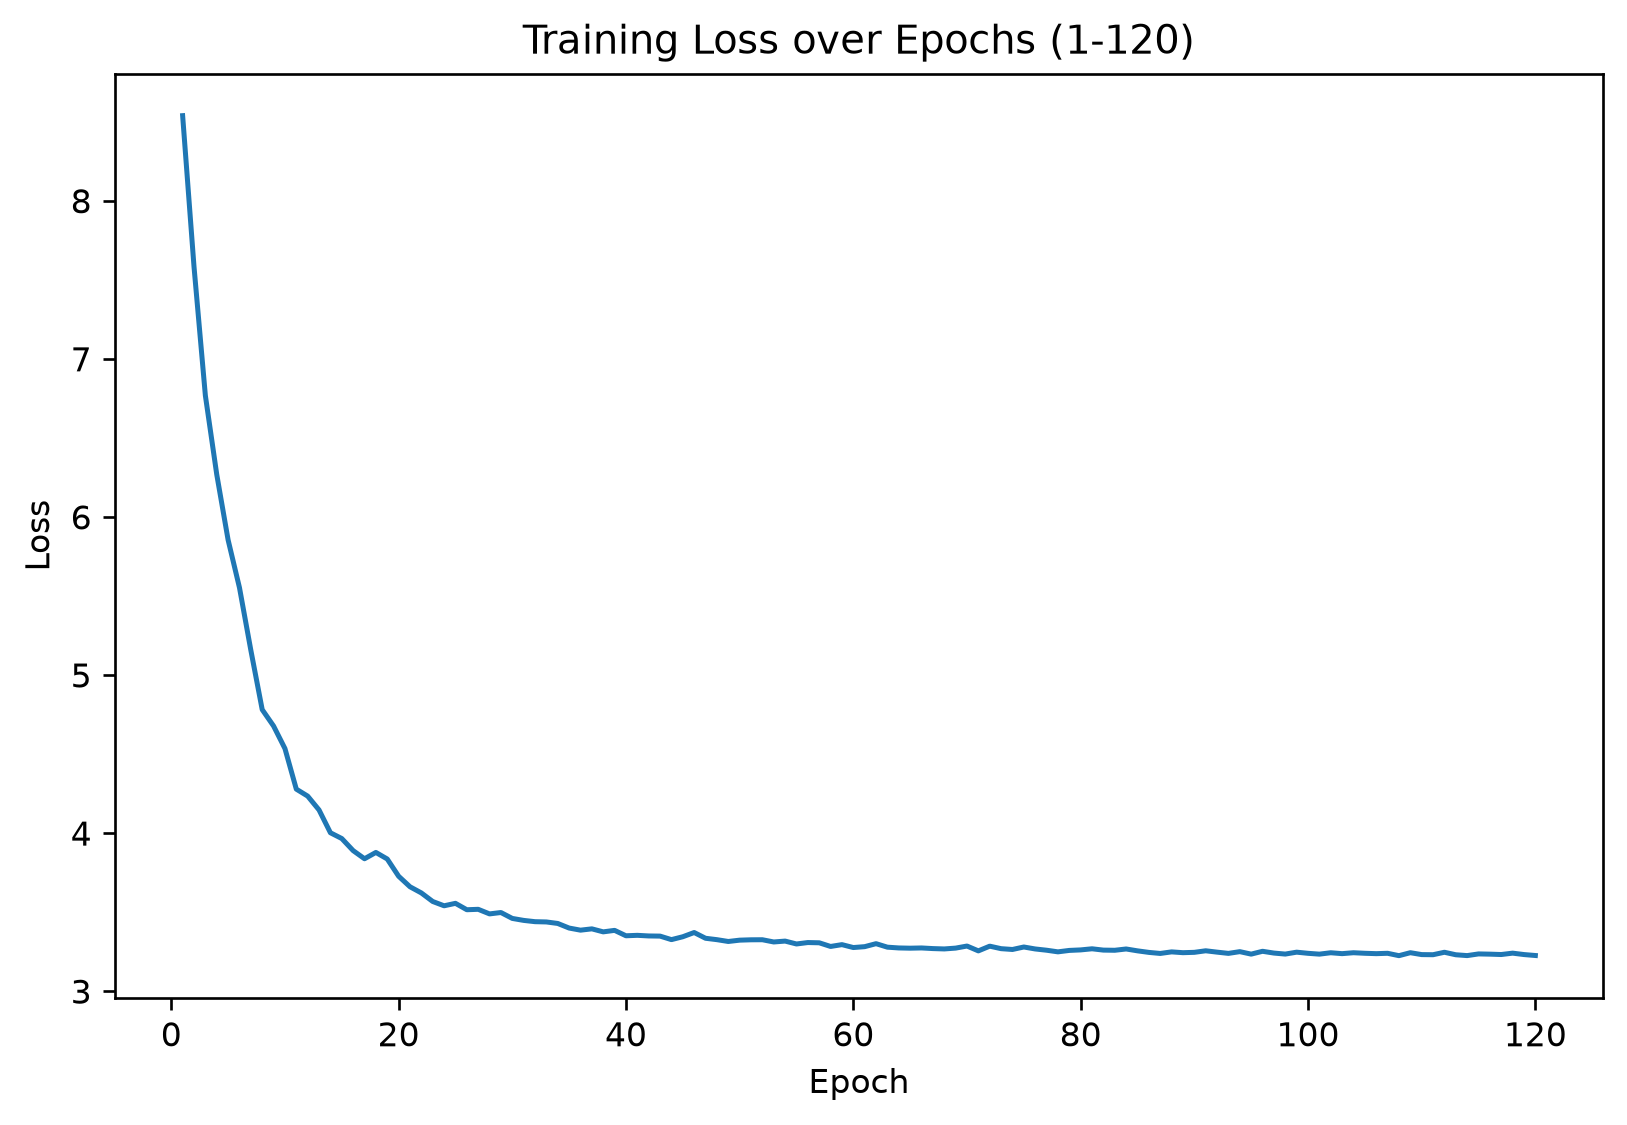

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("ssl_pretraining/output/model-2026-1002/history.csv")
# Remove unnecessary epoch 121
history = history[history["epoch"] != 121].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["epoch"], history["loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss over Epochs (1-120)")
plt.show()

In [14]:
# Inspect loss statistics and find the epoch with minimum loss
print("Loss statistics:")
print("")
print(history["loss"].describe())
print(f"\nMinimum loss: {history['loss'].min():.4f} at epoch {history.loc[history['loss'].idxmin(), 'epoch']:.0f}")

Loss statistics:

count    120.000000
mean       3.586836
std        0.836145
min        3.223921
25%        3.246151
50%        3.284413
75%        3.450123
max        8.537329
Name: loss, dtype: float64

Minimum loss: 3.2239 at epoch 108


In [15]:
w = checkpoint["weights"]["encoder.layer1.0.conv2.1.weight"]
w

tensor([0.9941, 1.0073, 0.9917, 0.9794, 1.0308, 0.9915, 1.0116, 1.0125, 0.9838,
        0.9902, 1.0018, 1.0126, 0.9647, 1.0363, 1.0007, 1.0031, 0.9813, 1.0189,
        0.9800, 1.0276, 0.9837, 0.9939, 0.9915, 1.0049, 1.0090, 1.0008, 1.0096,
        1.0051, 0.9921, 0.9964, 1.0019, 1.0111, 1.0195, 0.9841, 0.9983, 0.9977,
        0.9938, 0.9819, 0.9809, 1.0144, 0.9897, 0.9945, 1.0038, 0.9823, 1.0022,
        0.9754, 0.9807, 1.0002, 0.9974, 0.9913, 1.0032, 0.9813, 1.0035, 0.9844,
        1.0031, 1.0064, 0.9951, 1.0212, 0.9893, 0.9850, 0.9719, 0.9831, 0.9888,
        0.9923])

## Classify LVH

From `data/MeasurementsList.csv`



In [22]:
import polars as pl

lvh_df = lvh_labels(os.path.join(DATA_DIR, "MeasurementsList.csv"))

In [24]:
lvh_df

HashedFileName,split,IVSd,LVIDd,LVPWd,max_wall,lvh
str,str,f64,f64,f64,f64,i8
"""0X6014CB4AA2A5AA9""","""train""",0.958621,5.943165,0.984982,0.984982,0
"""0X56CBCEE293FFBE8B""","""train""",0.805389,4.591423,0.759108,0.805389,0
"""0X967F41BAF9502275""","""test""",1.01515,4.611009,0.93757,1.01515,0
"""0XB29625B76B5206B1""","""train""",1.090672,4.001347,1.07409,1.090672,0
"""0XCF6DB19DC419858""","""train""",0.879238,6.844116,0.708474,0.879238,0
…,…,…,…,…,…,…
"""0XE1B2B78EFCD6EFA8""","""train""",1.271319,5.254985,1.346645,1.346645,1
"""0XFEF99DB526E5018""","""train""",1.029292,5.369475,0.982706,1.029292,0
"""0X721D1E219A77259C""","""train""",0.749052,5.760682,0.791551,0.791551,0


In [25]:
lvh_df.write_csv(os.path.join(DATA_DIR, "MeasurementsList_Labelled.csv"))

## Finetuning LVH

Running `AS_detection/main.py` in this notebook.

